# 2 Second Tutorials: Tree Structure Visualization and Gene Analysis on Siletti-1
In the Second Tutorial, the dataset consists of 4,714 cells from the human midbrain red nucleus region, sourced from CELLXGENE. We provide the data download method here.

In [1]:
import requests
import anndata
import CellScope
import os
import numpy as np
url = "https://datasets.cellxgene.cziscience.com/5488ff72-58ed-4f0d-913c-1b6d4d8412b1.h5ad"
file_path = os.path.join("Test Data/", "Siletti-1.h5ad")
response = requests.get(url, stream=True)
if response.status_code == 200:
    with open(file_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
adata = anndata.read_h5ad("Test Data/Siletti-1.h5ad")
fea_raw = adata.X
cell_types = adata.obs['cell_type']
label = np.array(cell_types)

/opt/anaconda3/envs/test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.1 CellScope on Siletti-1

In [2]:
from scipy.sparse import issparse
fea_raw,fea_log,fea = CellScope.cs.Normalization(fea_raw)
fea_Fitting_1, Signal_Space, Center_index = CellScope.cs.Manifold_Fitting_1(fea)
if issparse(fea_Fitting_1):
    fea_Fitting_1 = fea_Fitting_1.toarray()
fea_Fitting_2, fitting_index, index_after_outlier_removal = CellScope.cs.Manifold_Fitting_2(fea_Fitting_1)
T_all_1 = CellScope.cs.GraphCluster(fea_Fitting_1)
T_all_2 = CellScope.cs.GraphCluster(fea_Fitting_2)
Y_Fitting_1 = CellScope.cs.Visualization(fea_Fitting_1)
Y_Fitting_2 = CellScope.cs.Visualization(fea_Fitting_2)

/opt/anaconda3/envs/test/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/test/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/test/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/test/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/envs/test/lib/python3.10/site-package

## 2.2 Tree Structure Visualization
CellScope can generate visualization results for the cells in each node of the tree structured visualization and save the results in the Res folder.

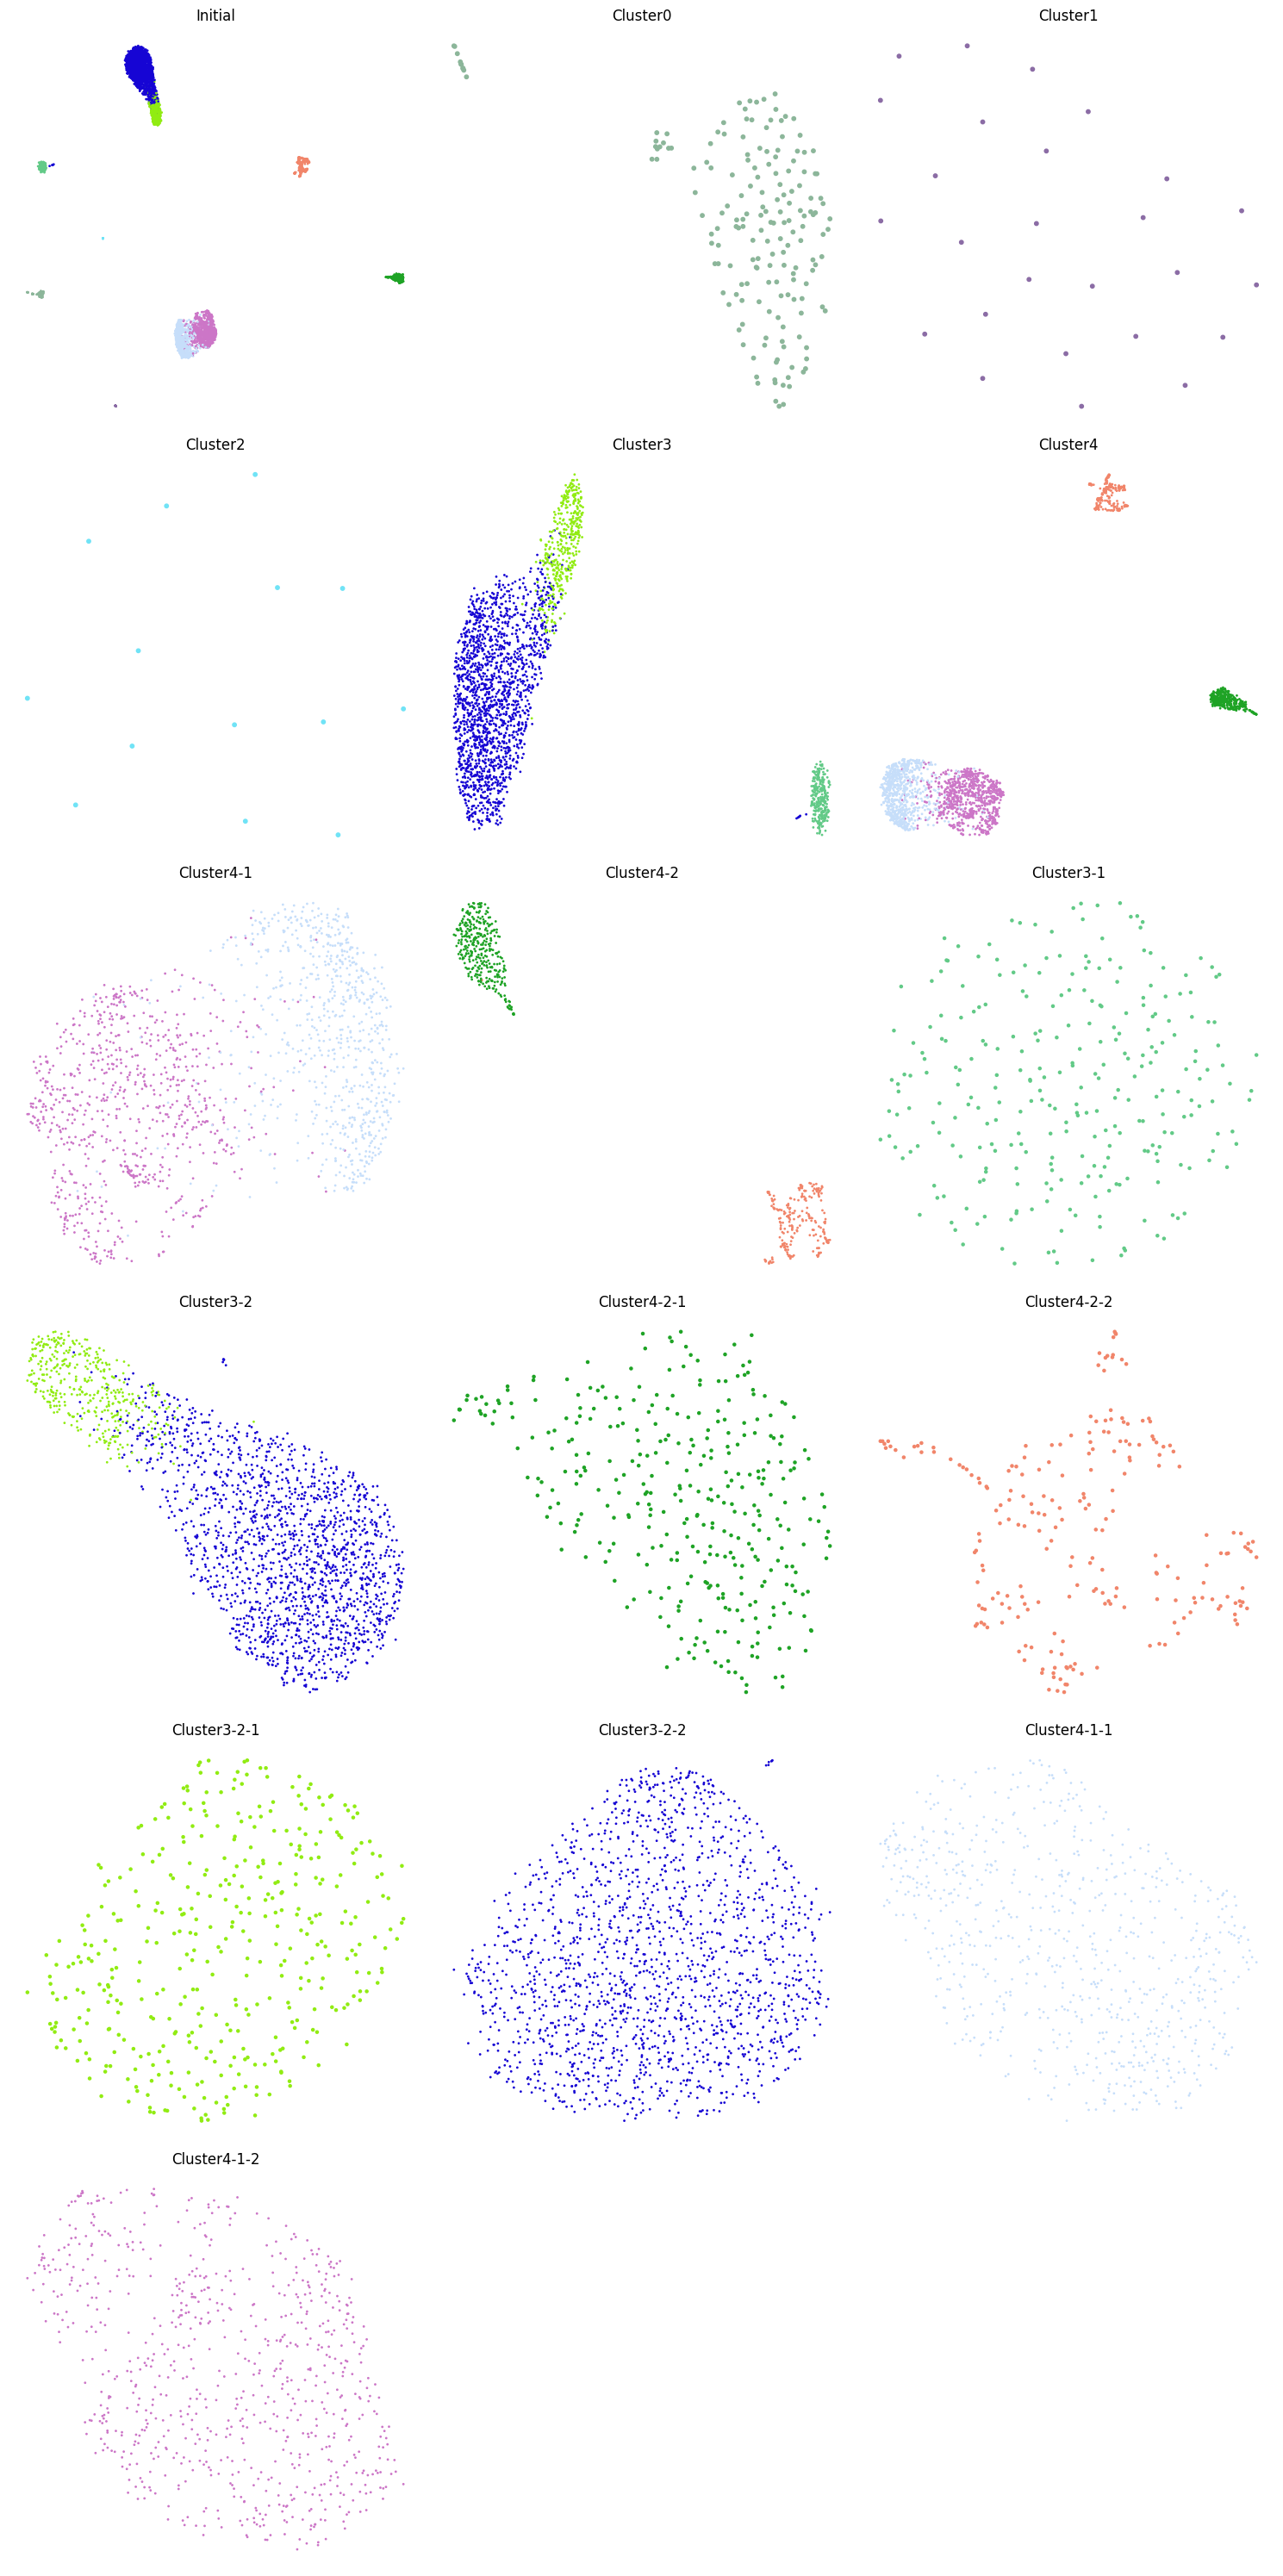

In [3]:
Y_initial, label_step0, Y_1, Title_1, Y_all, Title_all, index_1, index_all, step0, step1 = CellScope.ts.generate_tree_structured(fea_Fitting_1, T_all_1, step0 = None, step1 = 8)
CellScope.ts.visualize_tree_structured(Y_initial, label_step0, Y_1, Title_1, Y_all, Title_all, index_1, index_all, step0, step1, T_all_1, save_fig = True, save_path='Res')

## 2.3 Automatically Generate a Tree Structured Visualization
Automatically draw a tree structure diagram with three levels or fewer.

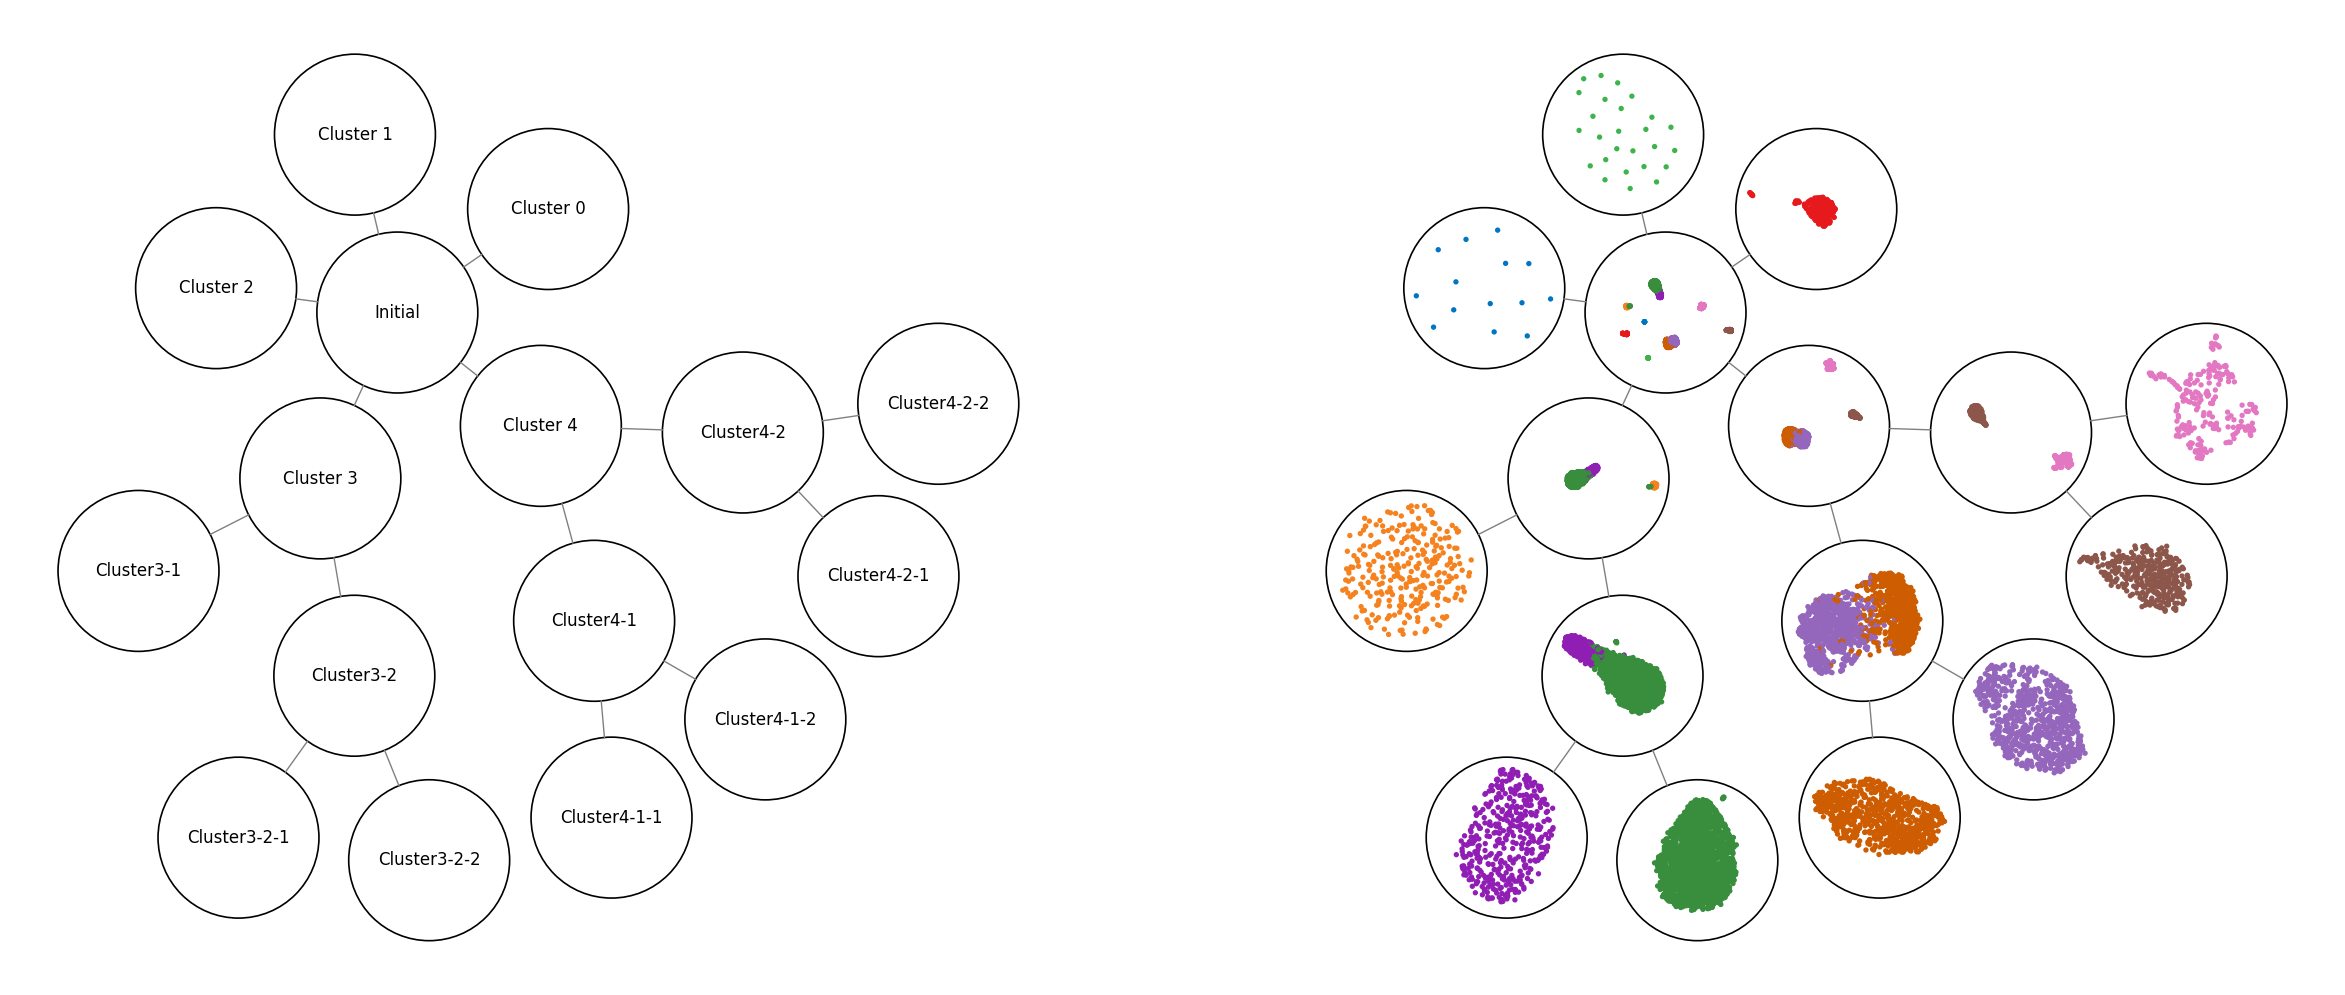

In [4]:
CellScope.ts.tree_structure_visualization_static(T_all_1,step0,step1,Title_1,Title_all,Y_initial,Y_1,Y_all,index_1,index_all, save_figure=True, filename="Res/tree_visualization_static.pdf")

## 2.4 Dynamically display a tree structure
To better visualize the hierarchical clustering process, CellScope provides dynamic rendering that demonstrates discriminative differences between cell types or subtypes.

In [5]:
CellScope.ts.tree_structure_visualization_dynamic(T_all_1,step0,step1,Title_1,Title_all,Y_initial,Y_1,Y_all,index_1,index_all,save_gif=True, 
                                       gif_filename="tree_animation.gif", dpi=100)

## 2.5 Stepwise Generation of Components for Tree-Structured Visualization
​​CellScope Provides Modular Components for Custom Dendrogram Assembly Using PDF Editors (e.g., Adobe Illustrator)​

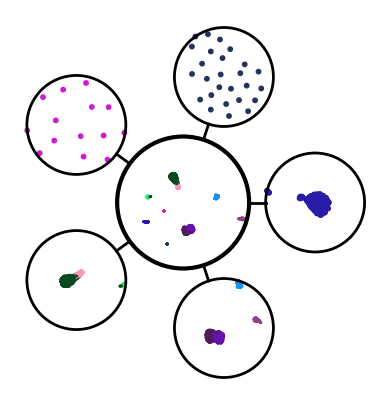

Cluster0


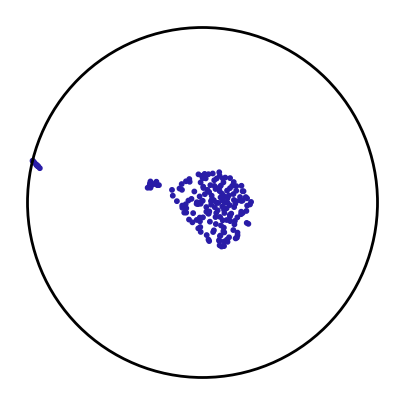

Cluster1


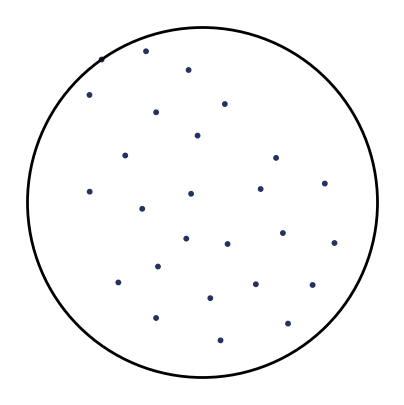

Cluster2


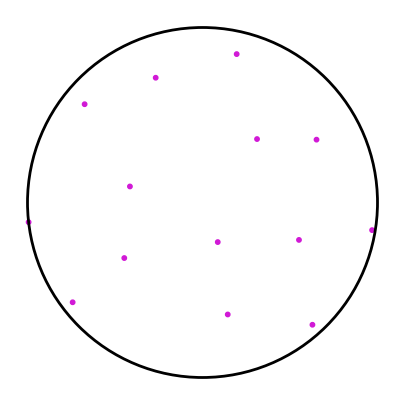

Cluster3


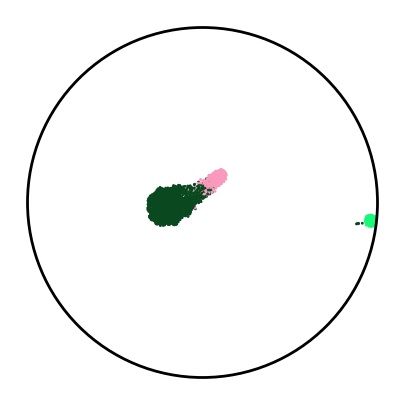

Cluster4


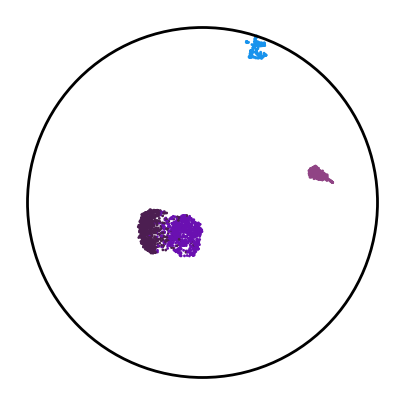

Cluster4-1&2


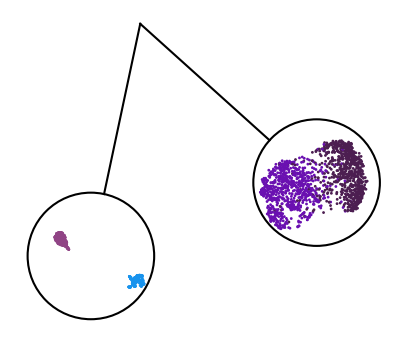

Cluster3-1&2


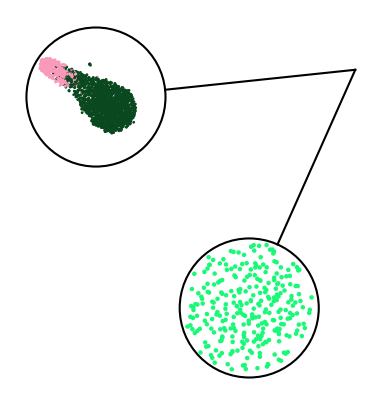

Cluster4-2-1&2


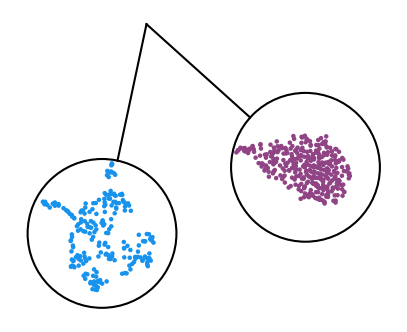

Cluster3-2-1&2


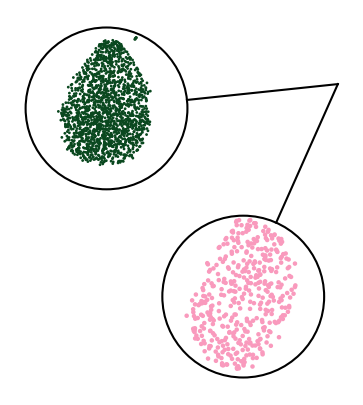

Cluster4-1-1&2


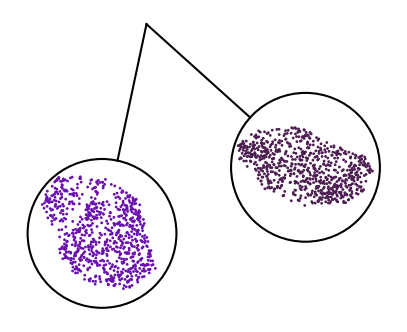

In [9]:
_,_ = CellScope.ts.tree_structure_visualization_step(T_all_1,step0,step1,Title_1,Title_all,Y_initial,Y_1,Y_all,index_1,index_all,main_radius=2.0,orbit_radius=1.5,
orbit_distance=4.0,branch_params=None,save_fig = True,save_path = '')

## 2.6 Visualization on Marker Gene
CellScope provides marker gene analysis functionality for your two cell types of interest, including violin plots, heatmaps, etc.

/var/folders/zv/dnfpd80s1bn80nj3xm8kwtd00000gn/T/ipykernel_79179/1443070485.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  marker_gene_name = Gene_Name[marker_gene_indices]
/Users/nth/Library/CloudStorage/OneDrive-个人/Macbook 文件/论文整理/新国立/CellScope/CellScope_Test/CellScope/gev.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_title(marker_gene_name[ii])


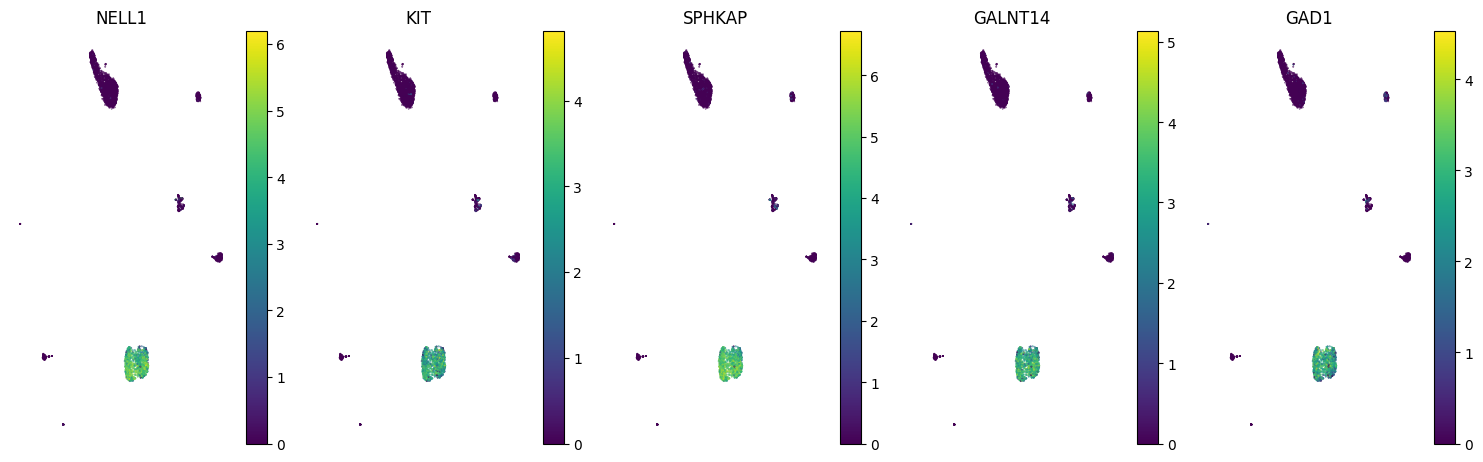

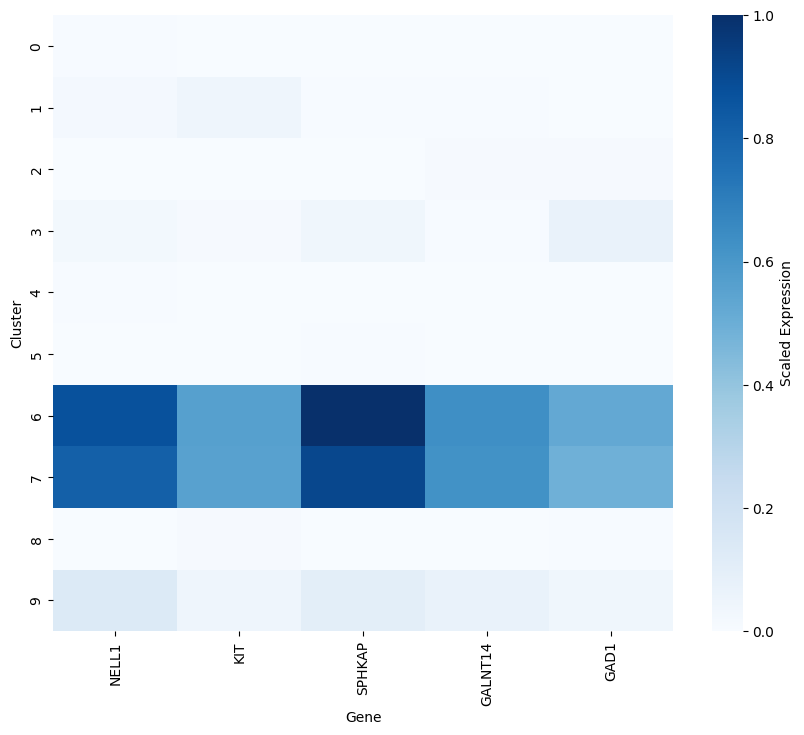

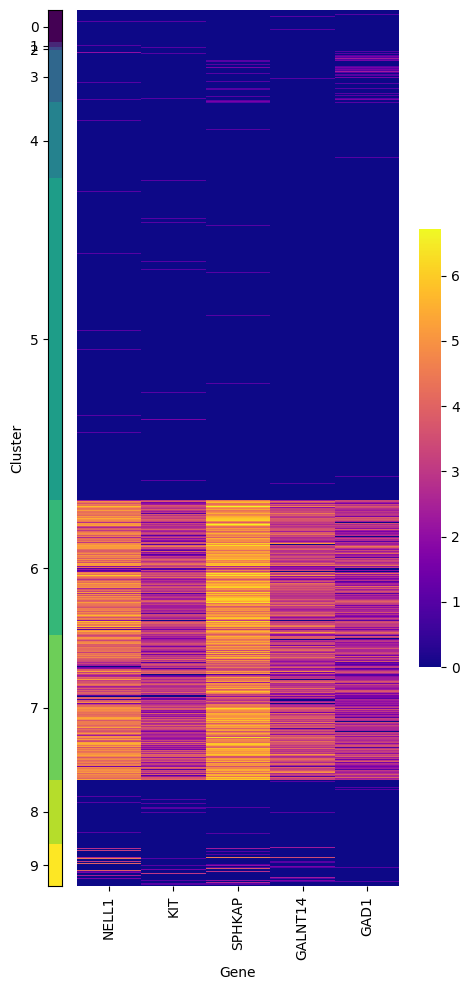

/Users/nth/Library/CloudStorage/OneDrive-个人/Macbook 文件/论文整理/新国立/CellScope/CellScope_Test/CellScope/gev.py:185: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0, ii].set_xlabel(marker_gene_name[ii])
/Users/nth/Library/CloudStorage/OneDrive-个人/Macbook 文件/论文整理/新国立/CellScope/CellScope_Test/CellScope/gev.py:185: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0, ii].set_xlabel(marker_gene_name[ii])
/Users/nth/Library/CloudStorage/OneDrive-个人/Macbook 文件/论文整理/新国立/CellScope/CellScope_Test/CellScope/gev.py:185: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys

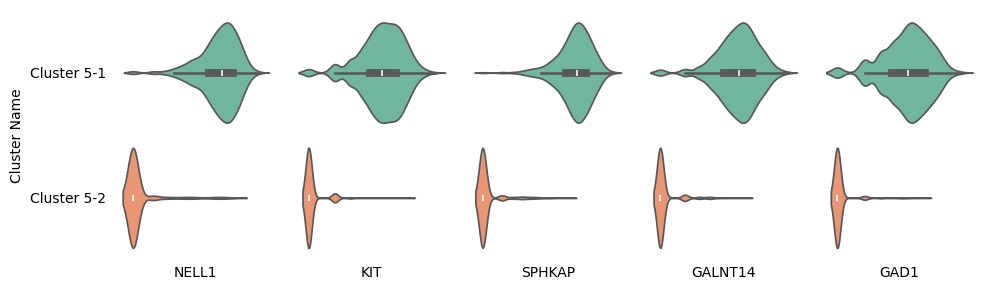

In [7]:
cluster1 = index_all[0]
cluster2 = index_all[1]
label = T_all_1[:,8]
Gene_Name = adata.var['feature_name']
marker_gene_indices,_ = CellScope.fm.FindMarker(fea_log, cluster1, cluster2, selected_number = 5, selected_method = 'diff pct')
marker_gene_name = Gene_Name[marker_gene_indices]
CellScope.gev.scatter_gene_expression(fea_log,Y_Fitting_1,marker_gene_indices,marker_gene_name,figsize=(15, 9), subplot_size = None, 
                            save_fig=False)
CellScope.gev.plot_mean_expression_heatmap(fea_log, marker_gene_indices,marker_gene_name, label,
                                           save_fig=False)
CellScope.gev.plot_clustered_heatmap(fea_log, marker_gene_indices, marker_gene_name, 
                           label, save_fig=False)
CellScope.gev.compare_violin_plot_between_classes(fea_log, marker_gene_indices, marker_gene_name, 
                                        cluster1, cluster2, class_name=['Cluster 5-1', 'Cluster 5-2'], 
                                        figsize=(10, 3), save_fig=False)

## 2.7 Gene Analysis
CellScope provides a hierarchical identity for each gene, indicating its different roles at varying resolutions. 

## ​Device-Specific Implementation Note:​​
The indices in variable layer must be dynamically adjusted based on Title_1 and Title_all to maintain consistent differentiation paths across hardware platforms.

In [ ]:
layer = [index_1[4],np.setdiff1d(range(T_all_1.shape[0]),index_1[1]),index_all[0],index_all[1],index_all[4],index_all[5]]
fea_log_array = fea_log.toarray()
Res, label, label_str, flow_labels = CellScope.ga.Gene_Analysis(fea_log_array,layer)
CellScope.ga.plot_sankey(label_str,save_fig=True, save_path='Res/sankey_diagram.pdf')

Figure saved to Res/sankey_diagram.pdf


,Layer 1,Layer 2,Layer 3
Housekeeper Gene,57952,57422,58480
Type-Related Gene,900,1193,436
Type-Determining Gene,384,621,320
